# **Examen Final**



## **Contexte**  
Le jeu de données **Extended Dirty Cafe Sales** est une version étendue de la base de données **Dirty Cafe Sales**, disponible sur [Kaggle](https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training/data). Il contient **60 500 lignes** de données synthétiques représentant des transactions de vente dans un café.  

Ce jeu de données a été volontairement altéré avec des valeurs manquantes, des incohérences et des erreurs pour simuler des défis réels liés à la qualité des données. Il constitue un excellent support pour la pratique du nettoyage des données, du traitement des valeurs aberrantes, de la structuration des données brutes et de l'analyse exploratoire des données.  

Dans le cadre de cet examen, vous devrez appliquer différentes techniques de nettoyage et de transformation afin d'assurer l'intégrité et la cohérence des données en vue d'une analyse fiable.



## **Informations sur le fichier**  
- **Nom du fichier** : `extended_dirty_cafe_sales.csv`  
- **Nombre de lignes** : **60 500**  
- **Nombre de colonnes** : **8**



## **Description des colonnes**  

| Nom de la colonne      | Description | Exemples |
|------------------------|-------------|----------|
| **Transaction ID** | Identifiant unique pour chaque transaction. Toujours présent et unique. | `0411639099547` |
| **Item** | Nom de l'article acheté. Peut contenir des valeurs manquantes ou invalides (ex. `"ERROR"`). | `Café`, `Sandwich` |
| **Quantity** | Quantité de l'article acheté. Peut contenir des valeurs manquantes ou invalides. | `1`, `3`, `"UNKNOWN"` |
| **Price Per Unit** | Prix unitaire de l'article. Peut contenir des valeurs manquantes ou invalides. | `2.00`, `4.00` |
| **Total Spent** | Montant total dépensé pour la transaction (calculé comme `Quantity * Price Per Unit`). | `8.00`, `12.00` |
| **Payment Method** | Méthode de paiement utilisée. Peut contenir des valeurs manquantes ou invalides (ex. `None`, `"UNKNOWN"`). | `Cash`, `Credit Card` |
| **Location** | Lieu où la transaction a eu lieu. Peut contenir des valeurs manquantes ou invalides. | `In-store`, `Takeaway` |
| **Transaction Date** | Date de la transaction. Peut contenir des valeurs manquantes ou incorrectes. | `2023-01-15` |  




## **Caractéristiques des Données**  

- **Valeurs Manquantes :**  
Certaines colonnes (ex. `Item`, `Payment Method`, `Location`) peuvent contenir des valeurs manquantes, représentées par `None` ou des cellules vides.  

- **Valeurs Invalides :**  
Certaines lignes contiennent des entrées invalides comme `"ERROR"` ou `"UNKNOWN"` afin de simuler des problèmes de données réels.

- **Cohérence des Prix :**  
Les prix des articles du menu sont cohérents, ex. `Total Spent = Quantity * Price Per Unit`, mais certaines valeurs peuvent être manquantes ou invalides.

- **Variation des prix :**
Les prix des articles ne sont pas fixes : ils évoluent d'une année à l'autre en raison de divers facteurs, tels que l'inflation, les prix de l'énergie, ou les changements de fournisseurs. Cependant, les prix sont les mêmes tout au long d'un année.



## **Chargement des données**

Pour charger les données, entrez simplement votre numéro d'étudiant (ex. : 24561985), puis exécutez la cellule suivante.

In [1]:
import pandas as pd

# Votre numéro étudiant
numero_etudiant = 20177272

# Chargement des données
file_ext = str(hash(str(numero_etudiant)) % 100).zfill(2)
df = pd.read_csv(f"https://raw.githubusercontent.com/hgueziri/MiscData/refs/heads/main/dirty_cafe_sales_{file_ext}.csv")

## **Travail à réaliser**




### Question 1

Explorez et analysez la base de données **Extended Dirty Cafe Sales** afin d'identifier les problèmes de qualité des données. Pour chaque problème détecté, vous devez :  

1. **Le décrire clairement (en 1-2 lignes)**, en expliquant son impact potentiel sur l'analyse des données.  
2. **Le justifier avec une cellule de code**, qui met en évidence l'anomalie à l'aide de visualisations, de résumés statistiques ou d'extractions ciblées.  

Vous pouvez ajouter autant de cellules de code que nécessaire pour analyser les différents aspects du jeu de données. Utilisez une cellule par problème identifié.

In [2]:
#exploration generale
df.describe()
df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60500 entries, 0 to 60499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    60500 non-null  int64 
 1   Item              57490 non-null  object
 2   Quantity          57065 non-null  object
 3   Price Per Unit    57365 non-null  object
 4   Total Spent       57700 non-null  object
 5   Payment Method    56959 non-null  object
 6   Location          57121 non-null  object
 7   Transaction Date  57007 non-null  object
dtypes: int64(1), object(7)
memory usage: 3.7+ MB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,6342639169159,Soda,UNKNOWN,1.76,5.28,Digital Wallet,Takeaway,2015-10-24
1,8863838491646,Soda,3,1.76,5.28,Cash,Takeaway,2015-02-03
2,7615117767451,Coffee,2,1.8,3.6,Digital Wallet,Takeaway,2015-10-21
3,6358788353141,Juice,2,3.14,6.28,Credit Card,In-store,2015-05-18
4,3001636719660,Yogurt,3,2.63,NaN,Digital Wallet,ERROR,2015-04-28
5,593349115608,Water,3,1.0,3.0,Digital Wallet,Takeaway,2015-04-26
6,9421706635982,Milk,3,2.04,UNKNOWN,Credit Card,In-store,2015-01-14
7,9928051626868,Soda,3,1.76,5.28,Digital Wallet,In-store,2015-04-08
8,5801547420192,Salad,2,4.39,8.78,Cash,Takeaway,2015-04-11
9,1421266596967,Tea,3,1.62,NaN,Cash,Takeaway,2015-12-24


**Justification**

Tout d'abord, on remarque que les types de données pour les différentes colonnes ne sont pas tous adéquats. Les prix (Price Per Unit et Total Spent) devraient être en float, pas en object; les dates (Transaction Dates) devraient être en datetimes, pas en object; et les quantités (Quantity) devraient être des int, pas en object, en vertu de ce que ces colonnes représentent concrètement et pour rendre les analyses et les manipulations plus faciles.

De plus, on remarque que le code pour les données absentes n'est pas standardisé, on a à faire à NaN, ERROR et UNKOWN, ce qui rend l'exclusion de ces données et leur traitement plus difficile.



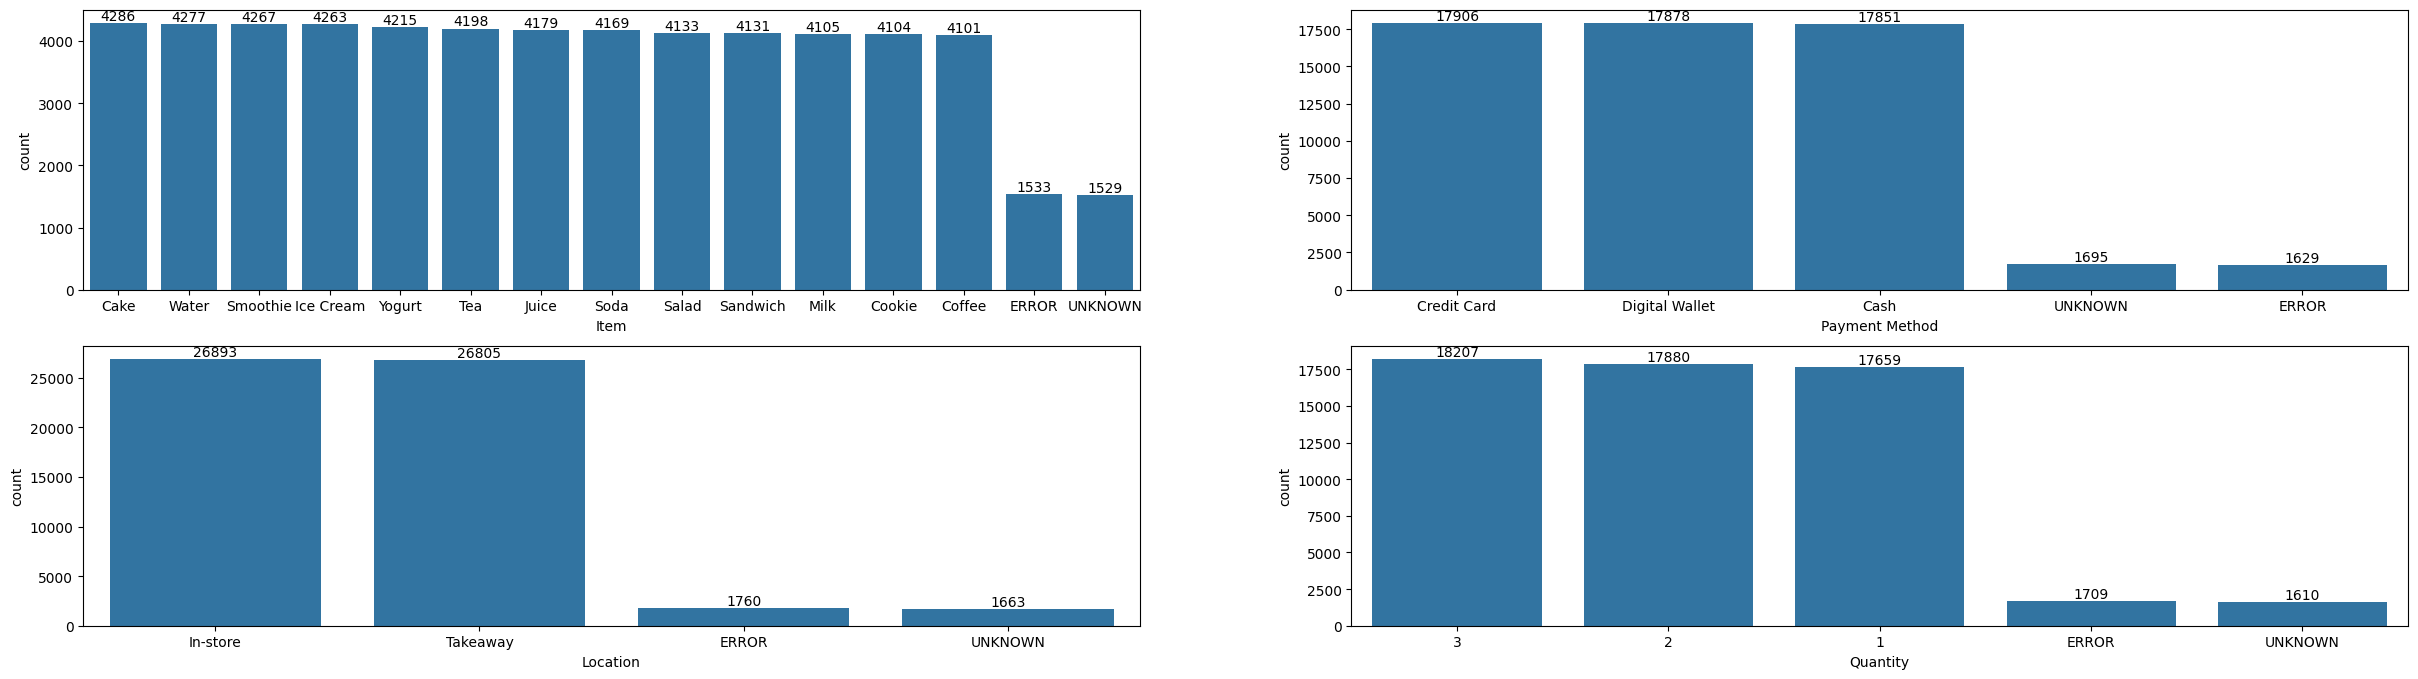

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(30, 8))
#distribution des Item order=df['feature_name'].value_counts(ascending=False).index
plt.subplot(2,2,1)
item = sns.countplot(x='Item', data=df, order=df['Item'].value_counts().index)
item_values = df['Item'].value_counts()
item.bar_label(item.containers[0], labels=item_values)
#distribution des Payment Method
plt.subplot(2,2,2)
payment = sns.countplot(x='Payment Method', data=df, order=df['Payment Method'].value_counts().index)
payment_values = df['Payment Method'].value_counts()
payment.bar_label(payment.containers[0], labels=payment_values)
#distribution des Location
plt.subplot(2,2,3)
location = sns.countplot(x='Location', data=df, order=df['Location'].value_counts().index)
location_values = df['Location'].value_counts()
location.bar_label(location.containers[0], labels=location_values)
#distribution des Quantity
plt.subplot(2,2,4)
quantity = sns.countplot(x='Quantity', data=df, order=df['Quantity'].value_counts().index)
quantity_values = df['Quantity'].value_counts()
quantity.bar_label(quantity.containers[0], labels=quantity_values)
plt.show()

**Justification**

Pour les colones qui ont très peu de valeurs possibles (au contraire des colonnes de prix par exemple qui ont des valeurs continues), on observe les valeurs qui existent pour chacune des colonnes.

On observe qu'on n'aura pas à gérer des variations d'orthographe pour une même valeur sémantique dans aucune des quatre colonnes observées, ou à gérer des valeurs non-entières pour les quantités. Cependant, chaque colonne contient des valeurs ERROR et UNKNOWN qui devraient être NaN afin de pouvoir plus facilement les manipuler dans les analyses. Ces valeurs erronées représentent environ 5% des valeurs dans la table, ce qui n'est pas négligeable lorsqu'on a à faire à une si grande quantité de données qu'on cherche à analyser et manipuler sans avoir à contourner ces valeurs erronées pour ne pas générer d'erreurs.

In [4]:
import re

#check format for dates
good_format=0
bad_format=0
bad_format_exemples=[]
error_format=0

for date in df['Transaction Date']:
  date=str(date).lower()
  if date!="unknown" and date!="error" and date!="nan" :
    matches = re.findall(r'^\d{4}-\d{2}-\d{2}?', date)
    if bool(matches):
      good_format+=1
    else:
      bad_format+=1
      bad_format_exemples.append(date)
  else:
    error_format+=1

print(f"good format : {good_format}")
print(f"bad format : {bad_format}")
print(f"error format : {error_format}")
print(f"bad format exemples : {bad_format_exemples}")

good format : 53627
bad format : 0
error format : 6873
bad format exemples : []


**Justification**

On s'assure que toutes les dates dans Transaction Date sont du format XXXX-XX-XX, où chaque X est un chiffre, à part les dates dont les valeurs sont UNKNOWN, ERROR ou NaN. De ce fait, on sait qu'on va pouvoir facilement toutes les transformer en datetime ou en NaN selon leur catégorie, sans avoir à écrire plusieurs types d'expressions régulières pour capturer toutes les options possibles et les manipuler pour qu'elles aient un format uniforme. De plus, la transformation en datetime est nécessaire pour toutes analyse temporelle qu'on souhaiterait faire sur cette colonne, car autrement les valeurs des dates sont traitées comme des strings sans compréhension de ce qu'elle représente réellement.

De plus, on remarque que dans cette colonne de valeurs quasi-continues, les valeurs erronées UNKNOWN, ERROR et NaN représentent plus de 10% des entrées, soit le double de la quantité de valeurs erronnée des colonnes de valeurs discrètes. Bien que cette différence soit intéressante, et qu'elle témoigne peut-être de contrôle du formatage en amont de la base de données, elle ne fait que nous indiquer qu'il y aura plus de valeur à unifier au NaN lors de la prochaine étape afin de pouvoir plus efficacement les manipuler dans les analyses.

In [5]:
#check format for prices per unit
good_format=0
bad_format=0
bad_format_exemples=[]
error_format=0
for price in df['Price Per Unit']:
  price=str(price).lower()
  if price!="unknown" and price!="error" and price!="nan" :
    matches = re.findall(r'^\d+\.\d{2}$', price)
    if bool(matches):
      good_format+=1
    else:
      bad_format+=1
      bad_format_exemples.append(price)
  else:
    error_format+=1

print(f"good format : {good_format}")
print(f"bad format : {bad_format}")
print(f"error format : {error_format}")
print(f"bad format exemples : {bad_format_exemples}")

good format : 49899
bad format : 4304
error format : 6297
bad format exemples : ['1.8', '1.0', '1.8', '5.4', '1.0', '0.39666666666666667', '1.0', '1.8', '1.0', '1.4033333333333333', '1.0', '1.0', '1.8', '1.0', '5.4', '1.8', '1.8', '1.8', '1.8', '1.8', '1.0', '1.0', '1.0', '1.0', '1.8', '3.0', '1.0466666666666666', '1.0', '1.0', '1.8', '1.0', '1.8', '1.8', '1.8', '1.0', '1.8', '13.169999999999998', '1.4633333333333332', '1.4033333333333333', '1.8', '1.0', '1.0', '1.8', '1.8', '1.0', '1.8', '1.0', '1.8', '1.0', '1.8', '1.0', '1.8', '1.0', '5.4', '1.0466666666666666', '1.0', '1.8', '1.8', '1.8', '1.0', '1.0', '1.0', '1.0', '0.3333333333333333', '1.8', '1.8', '1.8', '1.0466666666666666', '1.0', '1.0', '1.8', '1.0', '1.8', '0.9966666666666667', '1.2933333333333332', '1.8', '1.0', '1.0', '1.0', '1.4633333333333332', '1.8', '1.0', '1.8', '1.8', '1.8', '1.8', '1.8', '1.0', '0.8766666666666666', '1.0', '8.459999999999999', '1.8', '1.8', '1.0', '1.0', '0.8766666666666666', '0.39666666666666667',

**Justification**

On remarque que 4304 entrées sont d'un format non-standard d'au moins un chiffre, suivi d'un ".", suivant de deux chiffres. On utilise encore une expression régulière pour vérifier le formatage. En regardant rapidement les entrées mal formatées fournies en exemple on remarque qu'on a deux types d'erreurs de formatage, le surplus de valeurs décimales, et l'absence de la seconde valeur décimale. Dans les deux cas, il faudra ajuster le nombre de décimal accordé afin de refléter la réalité de la monnaie, qui ne permet pas plus ou moins que deux chiffres décimaux. Ceci permettra de mieux représenter la réalité, assurant ainsi une analyse plus juste, mais aussi d'assurer la compatibilité dans les calculs et la conversion fluide entre les formats utilisés pour représenter ces valeurs.

De plus, on remarque ici aussi que dans cette colonne de valeurs continues, les valeurs erronées UNKNOWN, ERROR et NaN représentent plus de 10% des entrées, soit le double de la quantité de valeurs erronée des colonnes de valeurs discrètes. Les mêmes remarques que faites dans la section précédente s'appliquent donc ici aussi.

In [6]:
#check format for total spent
good_format=0
bad_format=0
bad_format_exemples=[]
error_format=0
for price in df['Total Spent']:
  price=str(price).lower()
  if price!="unknown" and price!="error" and price!="nan" :
    matches = re.findall(r'^\d+\.\d{2}$', price)
    if bool(matches):
      good_format+=1
    else:
      bad_format+=1
      bad_format_exemples.append(price)
  else:
    error_format+=1

print(f"good format : {good_format}")
print(f"bad format : {bad_format}")
print(f"error format : {error_format}")
print(f"bad format exemples : {bad_format_exemples}")

good format : 49805
bad format : 4986
error format : 5709
bad format exemples : ['3.6', '3.0', '1.8', '16.2', '2.0', '0.4', '1.0', '5.4', '3.0', '1.4', '3.0', '3.0', '3.6', '1.8', '5.4', '3.0', '10.8', '1.8', '5.4', '1.8', '5.4', '5.4', '2.0', '2.0', '1.0', '2.0', '2.0', '1.8', '9.0', '1.0', '3.0', '1.8', '3.0', '5.4', '3.6', '1.8', '2.0', '5.4', '3.0', '5.4', '3.0', '3.6', '1.8', '2.0', '5.4', '1.0', '5.4', '2.0', '1.0', '5.4', '2.0', '5.4', '5.4', '16.2', '2.0', '3.6', '1.8', '3.6', '3.0', '3.0', '1.0', '3.6', '5.4', '3.6', '5.4', '3.6', '2.0', '3.0', '3.6', '2.0', '1.0', '1.8', '1.0', '3.0', '5.4', '3.0', '5.4', '5.4', '1.8', '3.6', '5.4', '3.0', '3.0', '5.4', '1.8', '2.0', '3.0', '2.0', '3.6', '1.0', '2.0', '3.6', '1.8', '1.0', '5.4', '5.4', '3.0', '2.0', '5.4', '2.0', '2.0', '1.0', '3.6', '2.0', '2.0', '3.6', '5.4', '5.4', '2.0', '3.0', '5.4', '5.4', '3.6', '5.4', '1.0', '1.8', '3.0', '3.0', '3.0', '5.4', '10.8', '3.0', '1.0', '5.4', '2.0', '5.4', '5.4', '3.6', '3.0', '3.0', '1.8'

**Justification**


On remarque dans cette colonne que 4986 entrées n'ont pas le format attendu décris plus haut, grâce à la même expression régulière. Dans cette colonne la seule erreur de formatage est l'absence de seconde décimale, donc on n'aura qu'à appliquer cette unique correction pour cette colonne afin d'avoir accès aux mêmes bénéfices analytiques que décrits plus haut.


De plus, on remarque aussi que dans cette colonne de valeurs continues, les valeurs erronées UNKNOWN, ERROR et NaN représentent un peu moins de 10% des entrées, soit le double de la quantité de valeurs erronée des colonnes de valeurs discrètes. Les mêmes remarques que faites dans la section précédant la précédente s'appliquent donc ici aussi.

In [7]:
#check si association possible entre prix et item
pd.set_option('display.max_rows', None)
print(df.groupby(['Item', 'Price Per Unit', 'Transaction Date']).count()['Transaction ID'])

Item       Price Per Unit       Transaction Date
Cake       0.9966666666666667   2015-04-22           1
                                2015-05-22           1
                                2015-08-13           1
                                2015-11-13           1
                                2015-11-14           1
           1.3833333333333335   2016-03-26           1
                                2016-04-22           1
                                2016-06-18           1
                                2016-09-16           1
                                2016-11-28           1
                                2016-12-27           1
                                2016-12-30           1
                                UNKNOWN              1
           1.5033333333333332   2017-01-02           1
                                2017-04-09           1
                                2017-04-15           1
                                2017-06-08           1
                

**Justification**

On vérifie si on peut associer chaque item avec un prix unitaire spécifique. Si c'est le cas, on peut extrapoler les items manquants dans la base de données à partir de leur prix unitaire s'il est présent, ce qui permettrait d'avoir plus de données pour les analyses qui incluent la colonne Item.

Cette longue liste révèle que le prix des items semble varier selon l'année, mais aussi que certains des prix unitaires sont soit erronés soit différents pour une raison qui nous est inconnue (rabais employé de 66%, achat de trios d'item identique comme un seul item, etc.). Ce genre d'erreurs/variations peuvent affecter les analyses sur le prix ainsi que les calculs de valeurs manquantes pour les colonnes total et quantité. Cependant, il n'y a pas de moyen pour corriger ces valeurs sans savoir si on affecte des valeurs qui étaient exactes et donc la divergence était une partie intrinsèque importance du système. On ne peut pas non plus utilisé les prix des items pour déduire ce qu'ils sont puisqu'il est possible qu'il soit une des instances de prix divergeant de cet item et que de leur associé une étiquette d'item erroné aurait un impacte sur l'analyse de ce dernier au lieu de simplement retirer l'entrée de l'analyse pour les items.

Donc on choisit de ne pas corriger les étiquettes des items ou les prix unitaires selon les tendances observées dans la liste afin de ne pas affecter les analyses avec des valeurs erronées. Si on avait des moyens de communication avec les employés ayant généré ces données, il pourrait être possible de mieux identifier si on fait face à un problème avec ces variations et comment le régler pour mieux représenter la réalité.



In [8]:
#check duplicates
has_duplicates=df['Transaction ID'].duplicated().any()
print('La base de données contient-elle des doublons de Transaction ID? '+str(has_duplicates))

La base de données contient-elle des doublons de Transaction ID? True


**Justification**


Finalement, on vérifie si la base de données contient des doublons. On affirme dans l'énoncée que les identifiants de transactions sont tous présents et qu'ils sont l'autorité suprême d'identification des transactions. Si on retrouve des identifiants présents plusieurs fois dans la base de données, ceci signifie qu'on devra passer à travers les  doublons pour en extraire le plus d'information possible pour se débarrasser des doublons en gardant le plus d'information possible.


La présence de doublons pourrait influencer les analyses en surreprésentant certaines valeurs alors qu'elles ne sont pas aussi présentes en réalité, donc il faut les éliminer afin de ne garder que les valeurs les plus exactes.

---

### Question 2

Corrigez les problèmes identifiés à la question 1 en suivant une approche méthodique.  

1. **Décrivez brièvement votre stratégie globale** : expliquez les étapes nécessaires pour nettoyer la base de données, en précisant l'ordre logique des corrections à appliquer.  
2. **Traitez chaque problème dans une cellule distincte** : pour chaque anomalie détectée, appliquez une solution adaptée et justifiez votre choix.  
3. **Incluez du code et des explications claires** : chaque correction doit être accompagnée d'une cellule de code qui applique la transformation nécessaire, suivie d'une brève explication des actions effectuées.  

Assurez-vous que les corrections préservent l'intégrité des données et améliorent leur qualité sans introduire de nouvelles incohérences.

**Stratégie globale**

**NaN universelle et type des données** :
On commence par transformer toutes les valeurs nulles ou érronées par un NaN universelle. Ensuite on force la conversion des colonnes en leur type de données appropriées (float pour les prix, int pour les quantité, date pour les date, string pour les items, les lieux et les types de paiement).

**Valeurs NaN calculables** :
Maintenant que les valeurs NaN sont facilement identifiables et que les données sont de types facilement manipulables, on essaye de remplir les valeurs manquantes pour les colonnes où c'est possible (prix, total et quantité si au moins deux des trois colonnes sont non-nulles). Comme on a noté à la question 1, on ne peut pas remplir les valeurs manquantes des items par les prix unitaire; et on n'a pas de moyen de deviner les valeurs des autres colonnes avec les informations présentes dans la table.

**Suppression de doublons** :
Fianlement, on utilise toutes les données dont on dispose maintenant pour déterminer quel doublon garder et quel retirer de la table afin de garder le plus d'information correcte possible.


In [9]:
#remplacer valeurs incorrecte pour NaN
import numpy as np

df.replace(['ERROR', 'UNKNOWN', None], np.nan, inplace=True)
df = df.convert_dtypes()

#convertir dtype de price per unit et total spent en float
df['Price Per Unit'] = df['Price Per Unit'].astype(float)
df['Total Spent'] = df['Total Spent'].astype(float)
#changer dtype de quantity en int
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
#changer dtype de date en datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

#vérifier les changements appliqués
df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60500 entries, 0 to 60499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    60500 non-null  Int64         
 1   Item              54428 non-null  string        
 2   Quantity          53746 non-null  Int64         
 3   Price Per Unit    54203 non-null  float64       
 4   Total Spent       54791 non-null  float64       
 5   Payment Method    53635 non-null  string        
 6   Location          53698 non-null  string        
 7   Transaction Date  53627 non-null  datetime64[ns]
dtypes: Int64(2), datetime64[ns](1), float64(2), string(3)
memory usage: 3.8 MB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,6342639169159,Soda,<NA>,1.76,5.28,Digital Wallet,Takeaway,2015-10-24
1,8863838491646,Soda,3,1.76,5.28,Cash,Takeaway,2015-02-03
2,7615117767451,Coffee,2,1.80,3.60,Digital Wallet,Takeaway,2015-10-21
3,6358788353141,Juice,2,3.14,6.28,Credit Card,In-store,2015-05-18
4,3001636719660,Yogurt,3,2.63,NaN,Digital Wallet,<NA>,2015-04-28
5,593349115608,Water,3,1.00,3.00,Digital Wallet,Takeaway,2015-04-26
6,9421706635982,Milk,3,2.04,NaN,Credit Card,In-store,2015-01-14
7,9928051626868,Soda,3,1.76,5.28,Digital Wallet,In-store,2015-04-08
8,5801547420192,Salad,2,4.39,8.78,Cash,Takeaway,2015-04-11
9,1421266596967,Tea,3,1.62,NaN,Cash,Takeaway,2015-12-24


**Justification**


On utilise la fonction replace pour rapidement remplacer toutes les valeurs nulles ou erronées par un type NaN manipulable et interprétable par pandas.


On utilise ensuite conver_dtypes pour traduire toutes les colonnes en string et les valeurs NaN de ces colonnes en format prêt à être transformé si le type de données change encore.


Ensuite, on convertit chaque colonne numérique ou de date en dtype approprié en utilisant diverses fonctions fournies par pandas. Ces fonctions transforment aussi les valeurs NaN en le type de valeur NaN approprié pour le type de la colonne concerné (eg : NaT pour les date au lieu de NaN ou NA). Ceci nous permet d'avoir des colonnes de types plus précis (comme int) sans avoir à utiliser le NaN qui est forcé d'être un float et empêche le casting des colonnes en certains autres types.


Finalement, on affiche le résultat des transformations pour s'assurer qu'aucune action non attendue ne se soit produite.

In [10]:
#calculer les valeurs manquantes
df['Price Per Unit'].mask(cond = df['Price Per Unit'].isna(), other = df['Total Spent']/df['Quantity'], inplace=True)
df['Total Spent'].mask(cond = df['Total Spent'].isna(), other = df['Price Per Unit']*df['Quantity'], inplace=True)
#assure le bon nombre de décimal
df['Price Per Unit'] = round(df['Price Per Unit'], 2)
df['Total Spent'] = round(df['Total Spent'], 2)
#vérifier les changements appliqués
df.info()
df.head(20)

/tmp/ipython-input-700568604.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price Per Unit'].mask(cond = df['Price Per Unit'].isna(), other = df['Total Spent']/df['Quantity'], inplace=True)
/tmp/ipython-input-700568604.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<FloatingArray>
[              3.14,                1.8,                1.8,
               4.21,               1.76,               2.63,
               2.63,           

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60500 entries, 0 to 60499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    60500 non-null  Int64         
 1   Item              54428 non-null  string        
 2   Quantity          53746 non-null  Int64         
 3   Price Per Unit    60143 non-null  Float64       
 4   Total Spent       60171 non-null  Float64       
 5   Payment Method    53635 non-null  string        
 6   Location          53698 non-null  string        
 7   Transaction Date  53627 non-null  datetime64[ns]
dtypes: Float64(2), Int64(2), datetime64[ns](1), string(3)
memory usage: 3.9 MB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,6342639169159,Soda,<NA>,1.76,5.28,Digital Wallet,Takeaway,2015-10-24
1,8863838491646,Soda,3,1.76,5.28,Cash,Takeaway,2015-02-03
2,7615117767451,Coffee,2,1.8,3.6,Digital Wallet,Takeaway,2015-10-21
3,6358788353141,Juice,2,3.14,6.28,Credit Card,In-store,2015-05-18
4,3001636719660,Yogurt,3,2.63,7.89,Digital Wallet,<NA>,2015-04-28
5,593349115608,Water,3,1.0,3.0,Digital Wallet,Takeaway,2015-04-26
6,9421706635982,Milk,3,2.04,6.12,Credit Card,In-store,2015-01-14
7,9928051626868,Soda,3,1.76,5.28,Digital Wallet,In-store,2015-04-08
8,5801547420192,Salad,2,4.39,8.78,Cash,Takeaway,2015-04-11
9,1421266596967,Tea,3,1.62,4.86,Cash,Takeaway,2015-12-24


**Justification**

On a séparé la complétion des valeurs manquantes de type float avec celle de type int, et on commence avec celle en float. On commence par utiliser la fonction mask pour trouver les valeurs manquantes et les remplacer par la valeur calculée à partir des autres colonnes, puisqu'on sait que :

- Price Per Unit = Total Spent / Quantity
- Total Spent = Price Per Unit * Quantity

On n'a pas à gerer la possibilité qu'une des valeurs dans le calcul soit NaN, puisque la valeur de la colonne deviendrait le même NaN qu'elle était avant d'être isolée et modifiée par le mask.

Ensuite, on s'assure que toutes les valeurs dans les colonnes float sont arrondies à deux décimales afin de représenter plus justement la monnaie.

Finalement, on affiche le résultat des transformations pour s'assurer qu'aucune action non attendue ne se soit produite, et que les transformations aient fonctionné.

In [11]:
#calculer les valeurs manquantes
df['Quantity'].mask(cond = df['Quantity'].isna(), other = round(df['Total Spent']/df['Price Per Unit']), inplace=True)
#lancer un erreur si on a une quantité de 0 ou négative
if df.loc[df['Quantity']<=0].shape[0] != 0:
  raise ValueError('Quantity cannot be 0')

#vérifier les changements appliqués
df.info()
df.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60500 entries, 0 to 60499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    60500 non-null  Int64         
 1   Item              54428 non-null  string        
 2   Quantity          60158 non-null  Int64         
 3   Price Per Unit    60143 non-null  Float64       
 4   Total Spent       60171 non-null  Float64       
 5   Payment Method    53635 non-null  string        
 6   Location          53698 non-null  string        
 7   Transaction Date  53627 non-null  datetime64[ns]
dtypes: Float64(2), Int64(2), datetime64[ns](1), string(3)
memory usage: 3.9 MB


/tmp/ipython-input-23812866.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].mask(cond = df['Quantity'].isna(), other = round(df['Total Spent']/df['Price Per Unit']), inplace=True)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,6342639169159,Soda,3,1.76,5.28,Digital Wallet,Takeaway,2015-10-24
1,8863838491646,Soda,3,1.76,5.28,Cash,Takeaway,2015-02-03
2,7615117767451,Coffee,2,1.8,3.6,Digital Wallet,Takeaway,2015-10-21
3,6358788353141,Juice,2,3.14,6.28,Credit Card,In-store,2015-05-18
4,3001636719660,Yogurt,3,2.63,7.89,Digital Wallet,<NA>,2015-04-28
5,593349115608,Water,3,1.0,3.0,Digital Wallet,Takeaway,2015-04-26
6,9421706635982,Milk,3,2.04,6.12,Credit Card,In-store,2015-01-14
7,9928051626868,Soda,3,1.76,5.28,Digital Wallet,In-store,2015-04-08
8,5801547420192,Salad,2,4.39,8.78,Cash,Takeaway,2015-04-11
9,1421266596967,Tea,3,1.62,4.86,Cash,Takeaway,2015-12-24


**Justification**


On s'attaque ensuite aux valeurs manquantes de type int. On utilise la même formule avec la fonction mask que dans les cellules précédentes, cette fois en utilisant l'équation Quantity = Total Spent / Price Per Unit.


Cependant, on court le risque de se retrouver avec une quantité non entière si une des valeurs Float est présente, mais erronée. On utilise déjà round pour transformé le résultat de la division du type Float à un Int, mais dans le cas où l'arrondissement produise un 0, on effectue un test pour lancé une erreur explicitant le problème qui est apparu. Spécifiquement, on vérifie si la quantité d'entrées donc la valeur dans la colonne Quantity est 0 ou négative est nulle.


Finalement, on affiche le résultat des transformations pour s'assurer qu'aucune action non attendue ne se soit produite, et que les transformations aient fonctionné.

In [12]:
#grouper données par ID et remplir les NaN par la prochaine valeur valide trouvé dans le groupe
df.groupby('Transaction ID').apply(lambda x : x.fillna(method='bfill'))
#drop les doublons sauf le premier (devrait contenir le plus d'info valide)
df.drop_duplicates(subset='Transaction ID', keep='first', inplace=True, ignore_index=True)
#affiche les résultats pour s'assuré de l'impacte de la transofrmation
df.info()
df.head(20)

/tmp/ipython-input-276389573.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.groupby('Transaction ID').apply(lambda x : x.fillna(method='bfill'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    55000 non-null  Int64         
 1   Item              49477 non-null  string        
 2   Quantity          54838 non-null  Int64         
 3   Price Per Unit    54833 non-null  Float64       
 4   Total Spent       54851 non-null  Float64       
 5   Payment Method    49181 non-null  string        
 6   Location          49193 non-null  string        
 7   Transaction Date  49139 non-null  datetime64[ns]
dtypes: Float64(2), Int64(2), datetime64[ns](1), string(3)
memory usage: 3.6 MB


/tmp/ipython-input-276389573.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Transaction ID').apply(lambda x : x.fillna(method='bfill'))


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,6342639169159,Soda,3,1.76,5.28,Digital Wallet,Takeaway,2015-10-24
1,8863838491646,Soda,3,1.76,5.28,Cash,Takeaway,2015-02-03
2,7615117767451,Coffee,2,1.8,3.6,Digital Wallet,Takeaway,2015-10-21
3,6358788353141,Juice,2,3.14,6.28,Credit Card,In-store,2015-05-18
4,3001636719660,Yogurt,3,2.63,7.89,Digital Wallet,<NA>,2015-04-28
5,593349115608,Water,3,1.0,3.0,Digital Wallet,Takeaway,2015-04-26
6,9421706635982,Milk,3,2.04,6.12,Credit Card,In-store,2015-01-14
7,9928051626868,Soda,3,1.76,5.28,Digital Wallet,In-store,2015-04-08
8,5801547420192,Salad,2,4.39,8.78,Cash,Takeaway,2015-04-11
9,1421266596967,Tea,3,1.62,4.86,Cash,Takeaway,2015-12-24


**Justification**


On commence par regrouper les données selon l'identifiant, tel que les doublons d'identifiant se retrouvent dans le même groupe. À l'intérieur de ce groupe, on remplit les valeurs manquantes par la prochaine valeur valide trouvée dans le groupe. Ceci permet d'assurer que le premier doublon du groupe contient le plus d'information valide possible. Puisqu'on a déjà calculé et complété les informations de quantité, prix unitaire et total dépensé, on n'a pas à s'inquiéter qu'une incohérence à ce niveau se glisse dans la table sans qu'on s'en rende compte.


Ensuite, on retire tous les doublons de la table en gardant seulement ce premier doublon, afin d'avoir une seule entrée par identifiant et d'avoir le plus d'information valide possible dans cette entrée.



---

### Question 3.1

Extrayez les prix des produits pour chaque année afin d'analyser leur évolution au fil du temps. Assurez-vous de structurer les données dans un *DataFrame* de manière claire pour faciliter la comparaison des variations annuelles des prix.



In [13]:
item_prices_by_year = df.groupby([pd.Grouper(key='Transaction Date', freq='YE'), 'Item'])['Price Per Unit'].mean().unstack()
item_prices_by_year.index = item_prices_by_year.index.year
print(item_prices_by_year)

Item                   Cake    Coffee    Cookie  Ice Cream      Juice  \
Transaction Date                                                        
2015               3.136722  1.894198   1.19737   2.861911   3.191725   
2016                 4.2725  2.256092  1.370706   4.201857   4.184305   
2017               4.663153  3.867438  1.768693   5.188165   5.258286   
2018               6.602064  4.414348  2.314268   6.122594   6.899859   
2019               7.605714  4.480782  2.499966   7.169679   8.268814   
2020               9.938746  5.947147  3.095428   9.819069   9.841772   
2021              11.294035  6.667397  3.421748   9.009737  10.273609   
2022              10.976087  7.455406  4.085833   9.480032  11.286748   
2023              12.575619   8.59754     4.332  11.159632  11.556167   
2024              14.053801  7.366558  4.571349   13.30354  13.748626   
2025              15.467342  9.857203  5.430954  14.982029  15.880544   

Item                  Milk      Salad   Sandwich  

**Explication**


On utilise le groupeby comme dans la question 1 pour extraire les prix selon les items et les dates, sauf que cette fois-ci on groupe les dates par années. Ensuite on fait la moyenne des prix regroupés, puisque les prix dans la même année varient comme expliqué dans la question 1. Finalement, on transforme la série en tableau 2D avec unstack et on transforme les index pour qu'il ne soit que l'année et non une date complète avant d'afficher le DataFrame résultant.


On choisit l'ordre des éléments dans le groupby afin que le tableau résultant utilise les items comme colonnes, ce qui permet de plus facilement visualiser l'évolution des prix pour chaque item individuel lorsqu'on descend dans la colonne, au lieu de devoir parcourir un rangé pour avoir le même effet, ce qui est moins clair pour l'oeil humain à cause des espaces entre les nombres à comparer.

### Question 3.2

Affichez la tendance de l'évolution des prix des produits au fil des années, en mettant en évidence l'impact de l'inflation. Utilisez une visualisation appropriée pour illustrer la variation des prix dans le temps et identifiez d'éventuelles hausses ou fluctuations marquantes.

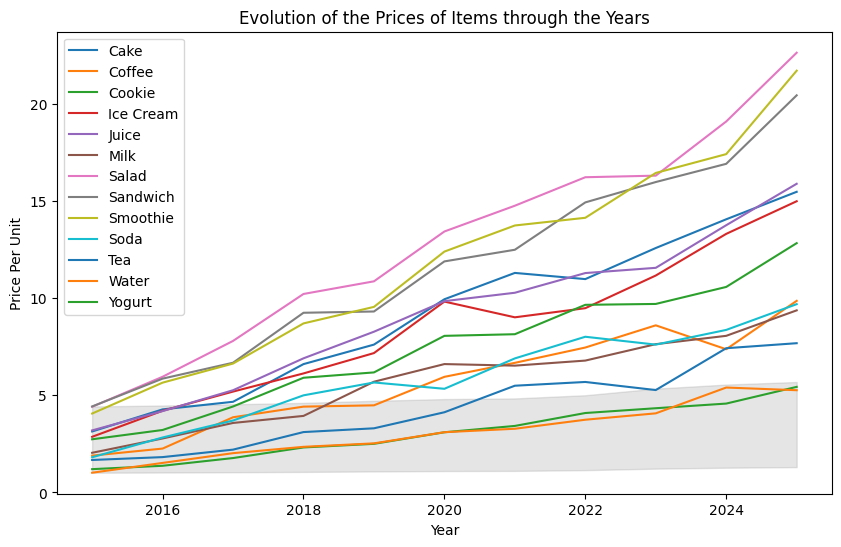

In [14]:
#mise en forme général du graphe, tab20 a assez de couleurs distinctes pour la quantité d'item à représenter
fig, ax = plt.subplots(figsize=(10, 6))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab20.colors)
#plot les prix calculés en question 3.1
ax.plot(item_prices_by_year)
#selon les statistiques 2015-2024 sur https://www.statsnwt.ca/prices-expenditures/cpi/historical_cpi/index.html
inflation_rates = [0, 1.1, 1.4, 1.6, 2.3, 1.9, 0.7, 3.4, 6.8, 3.9, 2.4]
#valeur max et min au début
init_max_prices = item_prices_by_year.max(axis=1)[2015]
init_min_prices = item_prices_by_year.min(axis=1)[2015]
max_prices = []
min_prices = []
#génération de l'évolution des prix
for i, rate in enumerate(inflation_rates):
  if i==0 :
    max_prices.append(init_max_prices)
    min_prices.append(init_min_prices)
  else :
    max_prices.append(max_prices[i-1]+(max_prices[i-1])*(rate/100))
    min_prices.append(min_prices[i-1]+(min_prices[i-1])*(rate/100))
#création du dataframe des prix attendus
expected_item_prices_by_year = pd.DataFrame(index=item_prices_by_year.index, columns=['max_prices', 'min_prices'], data=list(zip(max_prices, min_prices)))
#utilise le dataframe des prix attendus pour mettre en évidence la fenêtre dans laquelle les prix serait resté s'il suivait l'inflation
ax.fill_between(x=expected_item_prices_by_year.index, y1=expected_item_prices_by_year['max_prices'], y2=expected_item_prices_by_year['min_prices'], color='tab:gray', alpha=0.2)
#personalise les étiquettes pour refléter er expliquer les données
ax.set_xlabel('Year')
ax.set_ylabel('Price Per Unit')
ax.set_title('Evolution of the Prices of Items through the Years')
ax.legend(item_prices_by_year.columns, loc='upper left')
#afficher le grpahique construit
plt.show()

**Explication**


Dans le graphique, chaque droite représente l'évolution du prix d'un item, tel que l'indique la légende, et la zone en gris indique l'intervalle dans lequel les prix des items seraient restés si leur prix avait évolué comme l'indice d'inflation. On a calculé cet intervalle à partir des prix initiaux maximum et minimum des items et des taux d'inflation canadiens à travers les années 2015-2024.


On peut donc remarquer que les items ont largement augmenté en prix plus vite que ce que l'inflation enregistrée durant les années correspondantes aurait expliqué. Si on voulait utiliser d'autres indices d'inflation (par exemple si le café n'était pas au Canada, mais plutôt en Allemagne), on n'aurait qu'à changer les valeurs dans inflation_rates pour celles du pays correspondant pour les années utilisées comme index.


À l'intérieur des prix tels que représentés dans la base de données, on peut extraire quelques tendances intéressantes. Par exemple, en 2018, beaucoup d'items ont baissé en prix ou ont moins augmenté que ce que la courbe précédant cette année aurait prédit, à l'exception de la crème glacée, le lait et les sandwichs. Ou en 2025, tous les items ont augmenté en prix sauf le lait qui a diminué. Aucune autre variation en prix n'est vraiment globalement anormale.


On remarque aussi que les prix semblent s'agglomérer en sous-groupes qui restent proches en prix à travers le temps. Spécifiquement, les salades, les sandwichs et les smoothies sont le premier groupe d'item, représentant les items distinctement plus chers; suivirent des jus, des gâteaux et de la crème glacée comme deuxième groupe; puis le lait, le café et les sodas sont le troisième groupe; et finalement le thé, les biscuits et l'eau sont le dernier groupe, représentant les items les moins chers. Le yogourt est une anomalie dans ces regroupements puisqu'il commence dans le troisième groupe, mais, entre 2022 et 2024, augmente tellement en prix qu'il rejoint le deuxième groupe. De plus, le thé est associé au dernier groupe tentativement, puisqu'il se trouve presque toujours approximativement entre le troisième groupe et les autres membres du dernier groupe.


---

### Question 4

La base de données complémentaire **dirty_cafe_sales_comp.csv** contient des enregistrements supplémentaires provenant d'une deuxième caisse. Ces données sont considérées comme "propres", c'est-à-dire qu'elles ne présentent ni erreurs ni valeurs manquantes. Cependant, elles sont **incomplètes**, car cette caisse n'enregistre pas les prix des produits (`Price Per Unit`) ni le montant total dépensé (`Total Spent`).  

Votre tâche consiste à compléter ces informations en utilisant la base de données initiale **dirty_cafe_sales.csv**. Pour ce faire :  

1. **Récupérez les prix unitaires (`Price Per Unit`)** à partir de la base de données initiale en vous assurant qu'ils correspondent aux prix des produits pour chaque année donnée.  
2. **Calculez `Total Spent`** en appliquant la formule :

$$
   \text{Total Spent} = \text{Quantity} \times \text{Price Per Unit}
$$

3. **Vérifiez la cohérence des données**, notamment en vous assurant que les correspondances sont bien faites et qu'aucune valeur aberrante n'est introduite.  
4. **Combinez les deux bases de données** en un seul jeu de données consolidé. Assurez-vous qu'il n'y a pas de doublons, d'erreur, ou d'incohérence dans les données fusionnées. Le résultat doit être un DataFrame correctement indéxé et fonctionnel.  



In [15]:
# Chargement des données complémentaires
df_comp = pd.read_csv(f"https://raw.githubusercontent.com/hgueziri/MiscData/refs/heads/main/dirty_cafe_sales_comp_{file_ext}.csv")
df_comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1100 non-null   int64 
 1   Item              1100 non-null   object
 2   Quantity          1100 non-null   int64 
 3   Payment Method    1100 non-null   object
 4   Location          1100 non-null   object
 5   Transaction Date  1100 non-null   object
dtypes: int64(2), object(4)
memory usage: 51.7+ KB


In [16]:
#on tranforme les dates et les colonnes non-numeriques de df_comp en datetime et en str respectivement pour pouvoir les manipuler plus facilement
df_comp['Transaction Date'] = pd.to_datetime(df_comp['Transaction Date'])
df_comp = df_comp.convert_dtypes()

for index, row in df_comp.iterrows():
  #on extrait l'année de transaction et l'item acheté
  year = row['Transaction Date'].year
  item = row['Item']
  #on utilise le dataframe créé à la question 3.1 pour avoir les prix moyens par année pour tous les items connus
  price = item_prices_by_year.loc[year, item]
  #on calcul et assigne le prix unitaire et le total dépensé
  df_comp.at[index, 'Price Per Unit'] = price
  df_comp.at[index, 'Total Spent'] = row['Quantity'] * price
  #vérifie que valeurs calculées sont valides
  if df_comp.loc[index, 'Price Per Unit'] <= 0 or df_comp.loc[index, 'Total Spent'] <= 0 or pd.isnull(df_comp.loc[index, 'Price Per Unit']) or pd.isnull(df_comp.loc[index, 'Total Spent']):
    raise ValueError('Les valeurs calculées sont erronées.')

#concat df et df_comp
pd.concat([df, df_comp], ignore_index=True)
#retire les dublons selon Transaction ID, en gardant le dernier (celui originant de df_comp)
df.drop_duplicates(subset='Transaction ID', keep='last', inplace=True, ignore_index=True)
#affiche le résultat
df.info()
df.head(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    55000 non-null  Int64         
 1   Item              49477 non-null  string        
 2   Quantity          54838 non-null  Int64         
 3   Price Per Unit    54833 non-null  Float64       
 4   Total Spent       54851 non-null  Float64       
 5   Payment Method    49181 non-null  string        
 6   Location          49193 non-null  string        
 7   Transaction Date  49139 non-null  datetime64[ns]
dtypes: Float64(2), Int64(2), datetime64[ns](1), string(3)
memory usage: 3.6 MB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,6342639169159,Soda,3,1.76,5.28,Digital Wallet,Takeaway,2015-10-24
1,8863838491646,Soda,3,1.76,5.28,Cash,Takeaway,2015-02-03
2,7615117767451,Coffee,2,1.8,3.6,Digital Wallet,Takeaway,2015-10-21
3,6358788353141,Juice,2,3.14,6.28,Credit Card,In-store,2015-05-18
4,3001636719660,Yogurt,3,2.63,7.89,Digital Wallet,<NA>,2015-04-28
5,593349115608,Water,3,1.0,3.0,Digital Wallet,Takeaway,2015-04-26
6,9421706635982,Milk,3,2.04,6.12,Credit Card,In-store,2015-01-14
7,9928051626868,Soda,3,1.76,5.28,Digital Wallet,In-store,2015-04-08
8,5801547420192,Salad,2,4.39,8.78,Cash,Takeaway,2015-04-11
9,1421266596967,Tea,3,1.62,4.86,Cash,Takeaway,2015-12-24


**Explication**


On commence par transformer les dtypes des données de df_comp afin qu'elles soient plus faciles à manipuler pour les comparaisons et les calculs.


Ensuite, on trouve pour chaque entrée de df_comp le prix unitaire en utilisant le DataFrame créé à la question 3.1, appelée item_prices_by_year, qui associe à chaque Item à chaque année un prix moyen unitaire. Ce prix est ensuite utilisé pour calculer le total dépensé dans la transaction, et ces deux valeurs sont assignées à de nouvelles colonnes dans df_comp équivalente à celles déjà présentes dans df ('Price Per Unit' et 'Total Spent'). On s'assure de lancer une erreur si une des valeurs qu'on assigne est 0, NaN ou négative, puisque ceci indiquerait un problème en amont, soit dans la génération de la table item_prices_by_year ou dans les données de df_comp qui sont sensées être parfaitement "propres".


Ensuite on concatène la table df_comp résultante et la table df, puis on retire les doublons en gardant seulement le dernier, soit celui appartenant à l'origine à df_comp, puisque ces données sont sensées être plus propres et complète que ce que df contient.


Finalement on affiche le résultat afin de voir si les transformations ont eux des effets inattendus visibles.


---